In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import func_plot as fp
import seaborn as sns
import nibabel as nib
from scipy.stats import norm
atlas = nib.load('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order.dlabel.nii').get_fdata()[0]
atlas.shape

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


(64984,)

# Gradients Parcelwise PLS 10 LV

In [10]:
"""
single_pls_gradients.py (Jupyter / direct Python version)

Run one PLS model using all provided cortical gradients simultaneously.
"""

import os
import pickle
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from typing import List

# ------------------------
# Default configuration
# ------------------------
DEFAULT_GROUP_DEFINITIONS = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward',
                                'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

DEFAULT_OTHER_VARS = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
                      'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']

DEFAULT_COVARIATES = ['age', 'gender']

# ------------------------
# Helper functions
# ------------------------

def ensure_numeric_encoding(df, col):
    if col not in df.columns:
        return df
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].astype('category').cat.categories)}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_out(X, covariates):
    X_resid = np.zeros_like(X, dtype=float)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

def compute_variance_explained(pls, X_std, Y_std):
    X_scores = pls.x_scores_
    Y_scores = pls.y_scores_
    total_var_X = np.var(X_std, axis=0).sum()
    total_var_Y = np.var(Y_std, axis=0).sum()
    var_X_expl, var_Y_expl, shared_var = [], [], []
    for lv in range(pls.n_components):
        T = X_scores[:, lv:lv+1]
        U = Y_scores[:, lv:lv+1]
        P = pls.x_loadings_[:, lv:lv+1]
        Q = pls.y_loadings_[:, lv:lv+1]
        X_pred = T @ P.T
        Y_pred = T @ Q.T
        var_X_expl.append(np.var(X_pred, axis=0).sum() / (total_var_X + 1e-12))
        var_Y_expl.append(np.var(Y_pred, axis=0).sum() / (total_var_Y + 1e-12))
        if np.std(T[:,0]) == 0 or np.std(U[:,0]) == 0:
            shared_var.append(0.0)
        else:
            r = np.corrcoef(T[:,0], U[:,0])[0,1]
            shared_var.append(r**2)
    return var_X_expl, var_Y_expl, shared_var

def prepare_grouped_domains(df, group_defs):
    for group_name, var_list in group_defs.items():
        present = [v for v in var_list if v in df.columns]
        if len(present) == 0:
            print(f"Warning: none of variables for group '{group_name}' are present. Skipping.")
            continue
        zscored = df[present].apply(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-12), axis=0)
        domain_score = zscored.mean(axis=1)
        df[group_name] = -domain_score
    return df

def collect_parcel_columns(df, n_parcels_per_grad, n_grads):
    node_cols = [c for c in df.columns if c.startswith('node_')]
    if len(node_cols) == 0:
        raise ValueError('No parcel columns starting with "node_" found.')
    node_cols_sorted = sorted(node_cols)
    expected_total = n_parcels_per_grad * n_grads
    if len(node_cols_sorted) < expected_total:
        print(f"Warning: found {len(node_cols_sorted)} parcel columns but expected {expected_total}.")
    return node_cols_sorted

# ------------------------
# Main PLS script
# ------------------------

grad_files = ["g1_aligned_cog_updated.csv", "g2_aligned_cog_updated.csv", "g3_aligned_cog_updated.csv"]
grad_names = ["G1","G2","G3"]
subject_col = "subject_id"
n_components = 10
n_parcels_per_grad = 400
out_path = "results.pkl"

# 1) Load and rename
grad_dfs = []
for i, fpath in enumerate(grad_files):
    df = pd.read_csv(fpath)
    tag = grad_names[i]
    # Rename only node columns
    rename_map = {f'node_{j+1}': f'node_{j+1}_{tag}' 
                  for j in range(n_parcels_per_grad) if f'node_{j+1}' in df.columns}
    df = df.rename(columns=rename_map)
    
    if i == 0:
        # Keep all columns from the first CSV
        grad_dfs.append(df)
    else:
        # Keep only subject_col + node columns from subsequent CSVs
        cols_to_keep = [c for c in df.columns if c.startswith('node_')]
        if subject_col and subject_col in df.columns:
            cols_to_keep = [subject_col] + cols_to_keep
        grad_dfs.append(df[cols_to_keep])

# 2) Merge by subject_col
if subject_col and all(subject_col in df.columns for df in grad_dfs):
    merged = grad_dfs[0].copy()
    for df in grad_dfs[1:]:
        merged = merged.merge(df, on=subject_col, how='inner')
else:
    # fallback: align by row order
    print("Warning: subject_col missing or not in all files; aligning by row order.")
    lengths = [len(df) for df in grad_dfs]
    if len(set(lengths)) != 1:
        raise ValueError("Gradient files have unequal row counts.")
    merged = pd.concat(grad_dfs, axis=1)

# 3) Filter diagnoses
if 'diagnosis' in merged.columns:
    patient_df = merged[merged['diagnosis'].isin([2,3])].copy()
else:
    patient_df = merged.copy()

# 4) Numeric encoding
for col in DEFAULT_COVARIATES + ['diagnosis']:
    patient_df = ensure_numeric_encoding(patient_df, col)

# 5) Compute grouped domains
patient_df = prepare_grouped_domains(patient_df, DEFAULT_GROUP_DEFINITIONS)

# 6) Y columns
Y_cols = [c for c in DEFAULT_OTHER_VARS if c in patient_df.columns] + \
         [g for g in DEFAULT_GROUP_DEFINITIONS.keys() if g in patient_df.columns]
if len(Y_cols) == 0:
    raise ValueError("No Y variables found.")

# 7) X columns
parcel_cols = collect_parcel_columns(patient_df, n_parcels_per_grad, len(grad_files))
X = patient_df[parcel_cols].values
Y = patient_df[Y_cols].values

# 8) Remove NaNs
nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(Y).any(axis=1)
X_valid = X[nan_mask]
Y_valid = Y[nan_mask]
patient_valid = patient_df.loc[nan_mask].copy()
print(f"Using {X_valid.shape[0]} subjects after NaN removal.")

# 9) Regress out covariates
cov_present = [c for c in DEFAULT_COVARIATES if c in patient_valid.columns]
if len(cov_present) > 0:
    covars = patient_valid[cov_present].values
    X_resid = regress_out(X_valid, covars)
else:
    X_resid = X_valid.astype(float)

# 10) Standardize
X_std = StandardScaler().fit_transform(X_resid)
Y_std = StandardScaler().fit_transform(Y_valid.astype(float))

# 11) Fit PLS
pls = PLSRegression(n_components=min(n_components, X_std.shape[1], Y_std.shape[1]))
pls.fit(X_std, Y_std)

# 12) Compute variance explained
var_X_expl, var_Y_expl, shared_var = compute_variance_explained(pls, X_std, Y_std)

# 13) Save results
results = {
    'pls_model': pls,
    'X_std': X_std,
    'Y_std': Y_std,
    'parcel_cols': parcel_cols,
    'Y_cols': Y_cols,
    'var_X_expl': var_X_expl,
    'var_Y_expl': var_Y_expl,
    'shared_var': shared_var,
    'x_scores': pls.x_scores_,
    'y_scores': pls.y_scores_,
    'x_weights': pls.x_weights_,
    'y_weights': pls.y_weights_,
    'x_loadings': pls.x_loadings_,
    'y_loadings': pls.y_loadings_,
    'patient_df_valid': patient_valid
}

with open(out_path, 'wb') as fh:
    pickle.dump(results, fh)
print(f"Saved results to {out_path}")

summary_path = os.path.splitext(out_path)[0] + "_variance_summary.csv"
pd.DataFrame({
    "LV": np.arange(1, pls.n_components + 1),
    "X_var_frac": var_X_expl,
    "Y_var_frac": var_Y_expl,
    "shared_var_r2": shared_var
}).to_csv(summary_path, index=False)
print(f"Saved variance summary to {summary_path}")


Using 75 subjects after NaN removal.
Saved results to results.pkl
Saved variance summary to results_variance_summary.csv


## Permutation testing

In [11]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# -------------------------------
# Permutation testing parameters
# -------------------------------
n_permutations = 10000  # e.g., 10k
n_components = results['pls_model'].n_components
results_perm = {}

print("\nRunning permutation testing for SINGLE PLS model...")

# -------------------------------
# Retrieve standardized X and Y
# -------------------------------
X = results['X_std']  # standardized brain features (all gradients concatenated)
Y = results['Y_std']  # standardized behavioral data

# -------------------------------
# Fit original PLS
# -------------------------------
pls = PLSRegression(n_components=n_components)
pls.fit(X, Y)

# -------------------------------
# Compute observed singular values
# -------------------------------
obs_singular_values = np.zeros(n_components)
for lv in range(n_components):
    X_scores = pls.x_scores_[:, lv]
    Y_scores = pls.y_scores_[:, lv]
    obs_singular_values[lv] = np.cov(X_scores, Y_scores, bias=True)[0, 1]

# -------------------------------
# Run permutations
# -------------------------------
perm_singular_values = np.zeros((n_permutations, n_components))

for i in range(n_permutations):
    # Shuffle rows of X (breaks brain-behavior link)
    X_perm = X[np.random.permutation(X.shape[0]), :]
    
    pls_perm = PLSRegression(n_components=n_components)
    pls_perm.fit(X_perm, Y)
    
    for lv in range(n_components):
        X_scores_perm = pls_perm.x_scores_[:, lv]
        Y_scores_perm = pls_perm.y_scores_[:, lv]
        perm_singular_values[i, lv] = np.cov(X_scores_perm, Y_scores_perm, bias=True)[0, 1]
    
    if (i+1) % 1000 == 0:
        print(f"  {i+1}/{n_permutations} permutations complete...")

# -------------------------------
# Compute permutation p-values per LV
# -------------------------------
p_values = np.mean(perm_singular_values >= obs_singular_values[None, :], axis=0)

results_perm = {
    'obs_singular_values': obs_singular_values,
    'perm_singular_values': perm_singular_values,
    'p_values': p_values
}

# -------------------------------
# Print summary
# -------------------------------
print("\nPermutation-based LV significance:")
print(f"{'LV':>3} | {'Observed Cov':>14} | {'p-value':>8}")
print("-" * 33)
for lv in range(n_components):
    sig = "*" if p_values[lv] < 0.05 else " "
    print(f"{lv+1:>3} | {obs_singular_values[lv]:14.5f} | {p_values[lv]:8.4f} {sig}")

print("\nDone. Results stored in `results_perm` dictionary.")



Running permutation testing for SINGLE PLS model...
  1000/10000 permutations complete...
  2000/10000 permutations complete...
  3000/10000 permutations complete...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  4000/10000 permutations complete...
  5000/10000 permutations complete...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  6000/10000 permutations complete...


...

  7000/10000 permutations complete...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  8000/10000 permutations complete...
  9000/10000 permutations complete...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  10000/10000 permutations complete...

Permutation-based LV significance:
 LV |   Observed Cov |  p-value
---------------------------------
  1 |       31.70944 |   0.3871  
  2 |       24.66553 |   0.9207  
  3 |       28.40439 |   0.4584  
  4 |       39.75371 |   0.0353 *
  5 |       23.67405 |   0.7503  
  6 |       36.67148 |   0.0519  
  7 |       24.06626 |   0.5641  
  8 |       23.90618 |   0.4503  
  9 |       22.28660 |   0.4745  
 10 |       20.79499 |   0.4778  

Done. Results stored in `results_perm` dictionary.


## Permutation visualization

--> Red line far to the right of the histogram:
Observed covariance is larger than almost all permuted values → LV is significant (small p-value).

--> Red line overlapping the histogram:
Observed covariance is similar to what you’d see by chance → LV is not significant (p-value near 0.5 or higher).


Plotting permutation null distributions...


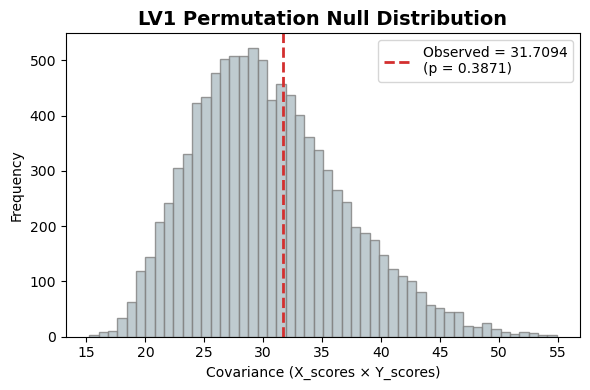

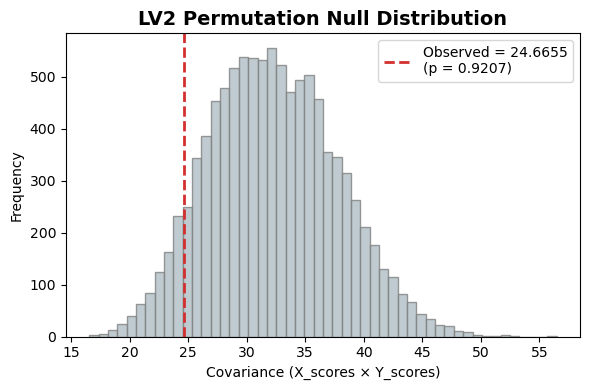

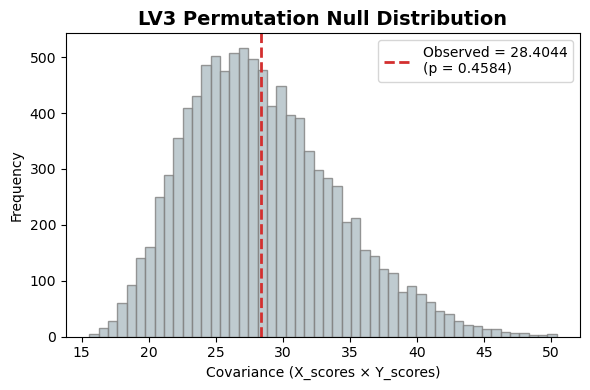

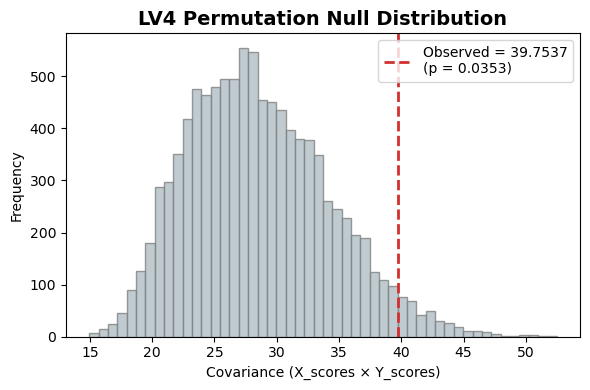

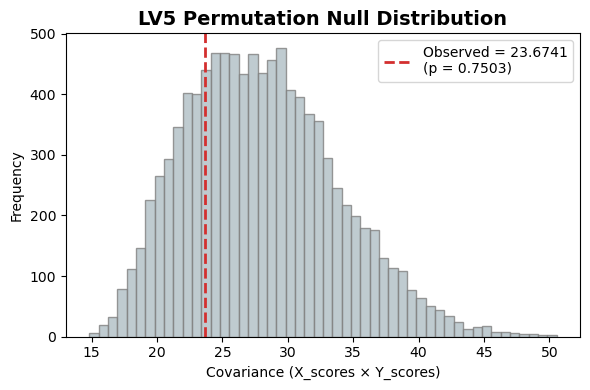

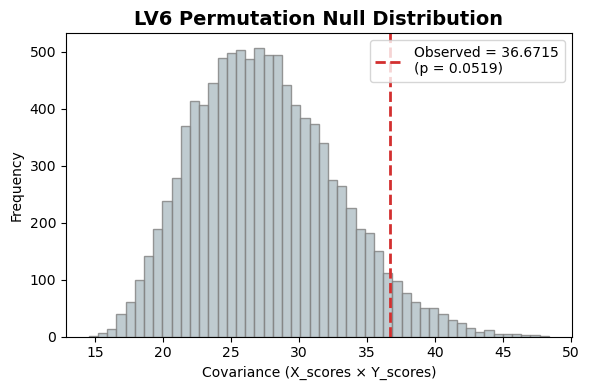

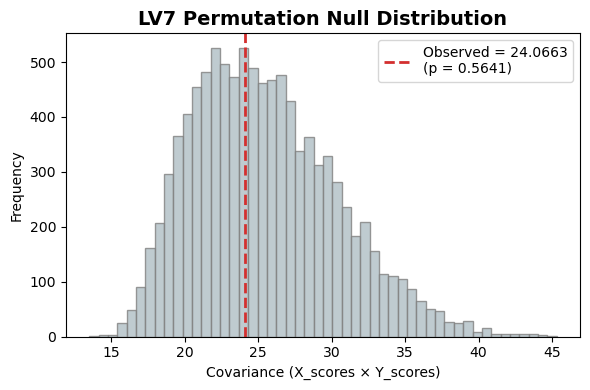

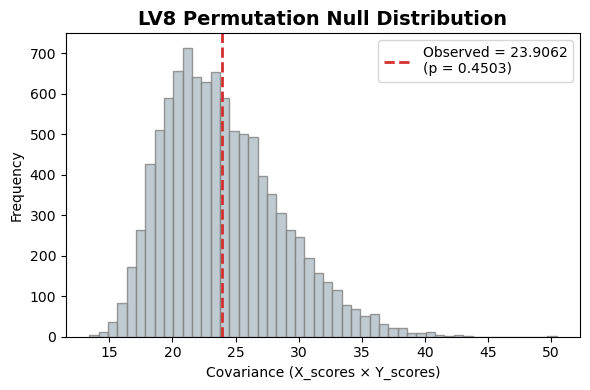

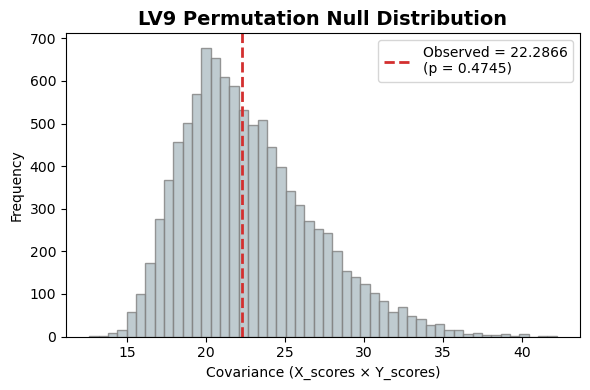

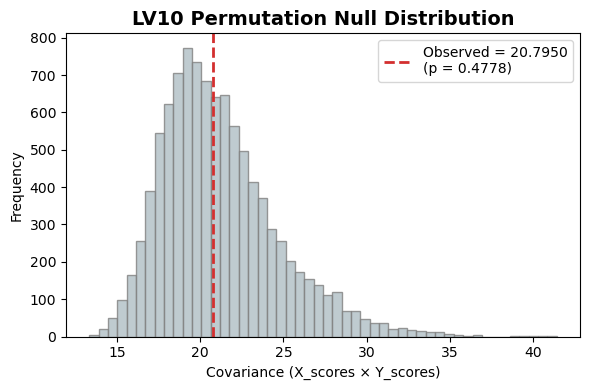

✅ Permutation histograms saved in 'figures_permutation/' and displayed.


In [12]:
import matplotlib.pyplot as plt
import os

# -------------------------------
# Create output folder
# -------------------------------
os.makedirs("figures_permutation", exist_ok=True)

# -------------------------------
# Extract permutation results
# -------------------------------
obs_vals  = results_perm['obs_singular_values']
perm_vals = results_perm['perm_singular_values']
p_vals    = results_perm['p_values']
n_components = len(obs_vals)

print("\nPlotting permutation null distributions...")

# -------------------------------
# Plot histogram per LV
# -------------------------------
for lv in range(n_components):
    plt.figure(figsize=(6, 4))
    
    # Null distribution
    plt.hist(
        perm_vals[:, lv],
        bins=50,
        color="#B0BEC5",
        edgecolor="gray",
        alpha=0.8
    )
    
    # Observed value
    plt.axvline(
        obs_vals[lv],
        color="#D32F2F",
        linestyle="--",
        linewidth=2,
        label=f"Observed = {obs_vals[lv]:.4f}\n(p = {p_vals[lv]:.4f})"
    )
    
    plt.title(f"LV{lv+1} Permutation Null Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Covariance (X_scores × Y_scores)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    
    # Save figure
    plt.savefig(f"figures_permutation/LV{lv+1}_permutation_hist.png", dpi=300)
    
    # Display
    plt.show()
    plt.close()

print("✅ Permutation histograms saved in 'figures_permutation/' and displayed.")


## Cross-validation

In [13]:
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr
import numpy as np

# -------------------------------
# Cross-validation parameters
# -------------------------------
n_splits = 5                            # 5-fold CV
n_components = results['pls_model'].n_components
results_cv = {}

print("\nRunning cross-validation for SINGLE PLS model...")

# Retrieve standardized X and Y
X = results['X_std']
Y = results['Y_std']

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
corr_list = np.zeros((n_splits, n_components))

# -------------------------------
# K-fold cross-validation
# -------------------------------
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train, Y_train)

    # Transform test X and compute predicted Y-scores
    X_test_scores = pls.transform(X_test)
    Y_test_scores = Y_test @ pls.y_weights_

    # Correlate predicted vs true Y-scores per LV
    for lv in range(n_components):
        r, _ = pearsonr(X_test_scores[:, lv], Y_test_scores[:, lv])
        corr_list[fold_idx, lv] = r

# Compute mean and standard deviation across folds
mean_corr = np.nanmean(corr_list, axis=0)
std_corr = np.nanstd(corr_list, axis=0)

results_cv = {
    'mean_corr': mean_corr,
    'std_corr': std_corr
}

# -------------------------------
# Print cross-validation summary
# -------------------------------
print("\nCross-validated PLS performance:")
print(f"{'LV':>3} | {'Mean Corr':>10} | {'SD':>8}")
print("-" * 28)
for lv in range(n_components):
    sig = "*" if mean_corr[lv] > 0.30 else " "
    print(f"{lv+1:>3} | {mean_corr[lv]:10.3f} | {std_corr[lv]:8.3f} {sig}")

print("\n✅ Cross-validation results stored in `results_cv`.")



Running cross-validation for SINGLE PLS model...

Cross-validated PLS performance:
 LV |  Mean Corr |       SD
----------------------------
  1 |      0.001 |    0.138  
  2 |     -0.237 |    0.206  
  3 |     -0.063 |    0.259  
  4 |     -0.220 |    0.164  
  5 |     -0.024 |    0.280  
  6 |     -0.037 |    0.166  
  7 |     -0.065 |    0.241  
  8 |      0.107 |    0.218  
  9 |     -0.102 |    0.097  
 10 |     -0.198 |    0.256  

✅ Cross-validation results stored in `results_cv`.


## Cross validation visualization
- Bar height (mean correlation) --> This is the average correlation between the predicted LV scores from cross-validation and the actual LV scores. It measures how well the LV pattern generalizes to unseen subjects.
Higher → the LV reliably captures brain–behavior covariance across different subsets of the data.
Close to 0 → the LV is not generalizing; it may only fit the training data.

- Error bars (standard deviation across folds) --> Indicates variability of the correlation across cross-validation splits.
Small error bar → LV is stable, consistent across different splits.
Large error bar → LV is unstable; its predictive pattern changes depending on which subjects are in the training set.

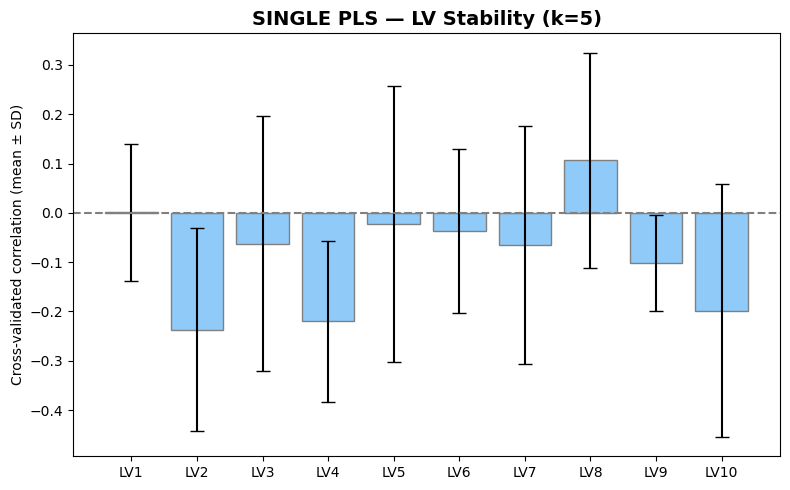

✅ Cross-validation stability plot saved to 'figures_cv/PLS_CV_stability.png' and displayed.


In [14]:
import matplotlib.pyplot as plt
import os
import numpy as np

# -------------------------------
# Create output folder
# -------------------------------
os.makedirs("figures_cv", exist_ok=True)

mean_corr = results_cv['mean_corr']
std_corr  = results_cv['std_corr']
n_components = len(mean_corr)
lv_labels = [f"LV{i+1}" for i in range(n_components)]

plt.figure(figsize=(8, 5))

# Bar plot with error bars (mean ± SD)
plt.bar(
    lv_labels,
    mean_corr,
    yerr=std_corr,
    capsize=5,
    color="#90CAF9",
    edgecolor="gray"
)

plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Cross-validated correlation (mean ± SD)")
plt.title(f"SINGLE PLS — LV Stability (k={5})", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save figure
out_path = "figures_cv/PLS_CV_stability.png"
plt.savefig(out_path, dpi=300)
plt.show()
plt.close()

print(f"✅ Cross-validation stability plot saved to '{out_path}' and displayed.")
